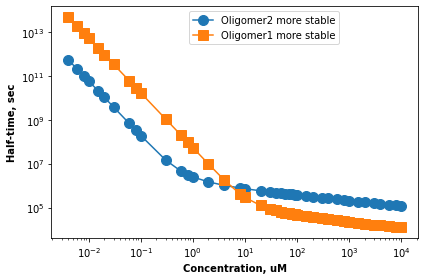

In [6]:
###### we consider equal oligomer size but different stability

## Figure 2C bottom row, left panel

import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import matplotlib.cm as cm
plt.close('all')


### Create lists for half-time, half-fibril mass and initial peptide concentration to plot half_time vs Conc plot
t50_alla=[]
fibril_alla=[]
Y0_alla=[]


for zzz in [ 5*10**(-4), 1*10**(-3)]:        ## changing ZZZ, we set up the different oligomer stability
    if zzz== 5*10**(-4):
        zzzz=5*10**(-5)
    else:
        zzzz=1*10**(-2)
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf1, 5Nf2, 6Phi_CR1, 7Phi_CR2, 8Kf1-p;1st-pathway, 9Kf1-;1st-pathway, 10Kf2-p;2nd-pathway, 11Kf2-;2nd-pathway, 12Kfrag, 13G1, 14G2] 
    p0=   [0,     0,    0,       0, 4, 4, 0.001, 0.001,    zzz, 5*10**(-8), zzzz, 5*10**(-8), 0,  6, 6 ]                  # Free parameters in our model 
    yy=[0.004,0.006,0.008, 0.01, 0.015, 0.02, 0.03, 0.06, 0.08, 0.1, 0.3, 0.6,0.8,1,2,4,8,10,20,31,40,50,60,70,80,90,100,150,200,300,400,600,800,1000,1500,2000,3000,4000,6000,8000,10000]                                  #### Discrete point initial peptide concentrations 
    n=len(yy)                                                                                                             #### Total discrete point concentration
    
    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u): 
        du = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]              # Introduce all states in our model
        
        #### Aproximate nf1+9 and truncate the high order dependency
        if t>0:
            if u[0]> p[6]:
                nf1plus1= u[18]  
            else:
                nf1plus1= u[18]*(u[0]/p[6])
        else:
            nf1plus1= 0     
        #### Aproximate nf2+9 and truncate the high order dependency   
        if t>0:
            if u[0]>p[7]:
                nf2plus1= u[27]
            else:
                nf2plus1= u[27]*(u[0]/p[7])
        else:
            nf2plus1= 0
         
        ### Define different terms 
        EEE1=  Kfn1*u[0]**p[4] - p[8]*u[4];                      # 1st-pathway oligomer number nucleation  
        EEE2=  Kfn2*u[0]**p[5] - p[10]*u[7];                     # 2nd-pathway oligomer number nucleation
        EE1=  p[4]*EEE1;                                         # 1st-pathway oligomer mass nucleation  
        EE2=  p[5]*EEE2;                                         # 2nd-pathway oligomer mass nucleation
        NNN1= (Kf1p*u[0]*u[4] - p[9]*u[10])*np.exp(-p[13])       # 1st-pathway oligomer to fibril seed conversion
        NNN2= (Kf2p*u[0]*u[7] - p[11]*u[19])*np.exp(-p[14])      # 2nd-pathway oligomer to fibril seed conversion
        NN1= (p[4]+1)* NNN1                                      # fibril mass from 1st-pathway oligomer to fibril seed conversion
        NN2= (p[5]+1)* NNN2                                      # fibril mass from 2nd-pathway oligomer to fibril seed conversion
        GG1= (Kf1p*u[0]-p[9])*u[5] +  p[9]* u[10];               # Growth and shrinking of the 1st-pathway fibril  
        GG2= (Kf2p*u[0]-p[11])*u[8] + p[11]* u[19];              # Growth and shrinking of the 2nd-pathway fibril 

         
        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2                  
        du[1] = 0      
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 
        du[6] = NN1 + GG1 
        du[7] = EEE2 - NNN2
        du[8] = NNN2 
        du[9] = NN2 + GG2
        #########################################################################
        du[10]= (Kf1p*u[0]*u[4]*np.exp(-p[13]) -(Kf1p*u[0] + p[9]*np.exp(-p[13]))*u[10] + p[9]*u[11])
        du[11]= (Kf1p*u[0]*u[10] -(Kf1p*u[0] + p[9])*u[11] + p[9]*u[12])
        du[12]= (Kf1p*u[0]*u[11] -(Kf1p*u[0] + p[9])*u[12] + p[9]*u[13])
        du[13]= (Kf1p*u[0]*u[12] -(Kf1p*u[0] + p[9])*u[13] + p[9]*u[14])
        du[14]= (Kf1p*u[0]*u[13] -(Kf1p*u[0] + p[9])*u[14] + p[9]*u[15])
        du[15]= (Kf1p*u[0]*u[14] -(Kf1p*u[0] + p[9])*u[15] + p[9]*u[16])
        du[16]= (Kf1p*u[0]*u[15] -(Kf1p*u[0] + p[9])*u[16] + p[9]*u[17])
        du[17]= (Kf1p*u[0]*u[16] -(Kf1p*u[0] + p[9])*u[17] + p[9]*u[18])
        du[18]= (Kf1p*u[0]*u[17] -(Kf1p*u[0] + p[9])*u[18] + p[9]*nf1plus1)
        #########################################################################
        du[19]= (Kf2p*u[0]*u[7]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[19] + p[11]*u[20])
        du[20]= (Kf2p*u[0]*u[19] -(Kf2p*u[0] + p[11])*u[20] + p[11]*u[21])
        du[21]= (Kf2p*u[0]*u[20] -(Kf2p*u[0] + p[11])*u[21] + p[11]*u[22])
        du[22]= (Kf2p*u[0]*u[21] -(Kf2p*u[0] + p[11])*u[22] + p[11]*u[23])
        du[23]= (Kf2p*u[0]*u[22] -(Kf2p*u[0] + p[11])*u[23] + p[11]*u[24])
        du[24]= (Kf2p*u[0]*u[23] -(Kf2p*u[0] + p[11])*u[24] + p[11]*u[25])
        du[25]= (Kf2p*u[0]*u[24] -(Kf2p*u[0] + p[11])*u[25] + p[11]*u[26])
        du[26]= (Kf2p*u[0]*u[25] -(Kf2p*u[0] + p[11])*u[26] + p[11]*u[27])
        du[27]= (Kf2p*u[0]*u[26] -(Kf2p*u[0] + p[11])*u[27] + p[11]*nf2plus1)
        
        return du
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x19=1*10**15; x18=1*10**14; x17=1*10**12; x16=1*10**8; x15=1*10**8; x14=1*10**7; x13=1*10**7;
    tend=[x19, x19, x19, x19, x19, x19,x18,x18,x18,x18,x17,x17,x17,x17,x16,x16,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13]
    
    ###################################################
    # Introduce lists to keep oligomer and fibril-mass evolution, and corresponding time
    total_fibril=[]
    total_time=[]
    oligomer1a=[]
    oligomer2a=[]
    fibril1a=[]
    fibril2a=[]
    #########################################################################
    for i in range(n):
        y0 = [yy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]  ## Introduce the initial condition
        p  = p0                                                             ## parameters in our model
        Kf1p = float(f"{p[9]/p[6]:.5e}")                                    ## Monomer-addition rate in 1st-pathway 
        Kf2p = float(f"{p[11]/p[7]:.5e}")                                   ## Monomer-addition rate in 2nd-pathway 
        Kfn1 = float(f"{(Kf1p*(Kf1p/p[8])**(p[4]-2)):.5e}")                 ## Oligomer nucleation rate in 1st-pathway 
        Kfn2 = float(f"{(Kf2p*(Kf2p/p[10])**(p[5]-2)):.5e}")                ## Oligomer nucleation rate in 2nd-pathway
        
        #### solve the rate-mass equations using solve_ivp
        tspan1 = (0,1)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 100000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF', atol=1e-10, rtol=1e-10)
            
        tspan2 = (1, 100)
        t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 100000)
        sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method='BDF', atol=1e-10, rtol=1e-10)
        
        tspan3 = (100, 10000)
        t_eval3 = np.logspace(np.log10(tspan3[0]), np.log10(tspan3[1]), 100000)
        sol3 = solve_ivp(func0, tspan3, sol2.y[:, -1], t_eval=t_eval3, method='BDF', atol=1e-10, rtol=1e-10)
        
        tspan4 = (10000, tend[i])
        t_eval4 = np.logspace(np.log10(tspan4[0]), np.log10(tspan4[1]), 100000)
        sol4 = solve_ivp(func0, tspan4, sol3.y[:, -1], t_eval=t_eval4, method='BDF', atol=1e-10, rtol=1e-10)
            
        sol_t = np.concatenate((sol1.t, sol2.t, sol3.t, sol4.t))
        sol_y = np.hstack((sol1.y, sol2.y, sol3.y, sol4.y))
        
        #### append the value in the list 
        total_fibril.append(sol_y[6] + sol_y[9] )  ## append the fibril mass evolution in the list
        total_time.append(sol_t)                   ## append the time-measured in the list
        oligomer1a.append(p[4]*sol_y[4])           ## append the oligomer1 mass evolution in the list                         
        oligomer2a.append(p[5]*sol_y[7])           ## append the oligomer2 mass evolution in the list          
        fibril1a.append(sol_y[6])                  ## append the fibril1 mass evolution in the list
        fibril2a.append(sol_y[9])                  ## append the fibril2 mass evolution in the list
        
        ####plot the time evolution of species
        #plt.plot(sol_t,sol_y[0, :],'k',linewidth = 5)
        #plt.plot(sol_t, p[4]*sol_y[4, :],'y',linewidth = 5)
        #plt.plot(sol_t, p[5]*sol_y[7, :],'b',linewidth = 5)
        #plt.plot(sol_t, sol_y[6, :],'r',linewidth = 5)
        #plt.plot(sol_t, sol_y[9, :],'g',linewidth = 5)
        #plt.plot(sol_t, sol_y[6, :] + sol_y[9, :],'purple',linewidth = 5)
        #plt.ylabel('Mass concentration (\u03bcM)',fontsize=15)
        #plt.xlabel('Time (s)',fontsize=15)
        #plt.xticks(fontsize=10)
        #plt.yticks(fontsize=10)
        #plt.xscale('log')
        #myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Fibril1','Fibril2','Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1)) 
        #plt.tight_layout()
        #plt.savefig(f'xxxx.eps', dpi=300)
        #plt.show()
   ###########################################################################################   
    #Find T_Half for each concentration
    t50=[]   
    fibril50=[]
    Y050=[]
    Y0= yy 
    for i in range(n):
        cutoff_value = (Y0[i]-p[7])/2        #specified cutoff value for half-time
        list_I=total_fibril[i]              
        list_II=total_time[i]
        # Iterate through elements in List I
        for value_I, value_II in zip(list_I, list_II):
            if value_I >= cutoff_value:
                selected_value_I = value_I
                selected_value_II = value_II
                fibril50.append(selected_value_I)
                t50.append(selected_value_II)
                Y050.append(Y0[i])
                break                      # Break out of the loop once the condition is met
    t50_alla.append(t50)
    fibril_alla.append(fibril50)
    Y0_alla.append(Y050)
############################################################################################## 

### Plot the T_half vs Concentration
markers = ['o', 's', '^', 'D', '*']  
#plt.figure(figsize=(9, 5))
for i, (sublist1, sublist2) in enumerate(zip(Y0_alla, t50_alla)):
    plt.loglog(sublist1, sublist2, marker=markers[i], markersize=10, linestyle='-')  # Different marker for each curve
plt.ylabel('Half-time, sec', fontweight='bold')
plt.xlabel('Concentration, uM', fontweight='bold')
plt.legend(['Oligomer2 more stable', 'Oligomer1 more stable'], bbox_to_anchor=(0.8, 1), loc='upper right')
plt.tight_layout()
#plt.savefig('Fig_2C_bottom1.eps', dpi=300)
plt.show()  